In [1]:
# from src.MPOptoClass import *
from src.utils.gen_utils import *
from src.utils.filters import *
from src.experiment import *
from src.wiener_filter import *
from src.modeller import *
from src.MPRecordClass import *
from src.ReachingClass import *
from src.analysis import *
import scipy
import copy
import time
import mat73 
import pynapple as nap
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colormaps
import random
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from itertools import permutations, compress, product
from tqdm import tqdm




%load_ext autoreload 
%autoreload 2
%matplotlib widget

In [194]:
import re
session_name_list=[]
session_path_list=[]
to_path = '../data/to'

for root, dirs, files in os.walk(to_path, topdown=True):
    for name in dirs:
        if re.search('to._', name) or re.search('to.._', name):
            session_name_list.append(name)
            session_path_list.append(os.path.join(root, name))

In [125]:
session_path = '../data/co/co9/co9_12122023'
session = MPOptoClass(session_path)

love


# does zscoring fix the issue

In [126]:
laser_bounds, ctrl_bounds = session.adjustLaserBounds(pre=100, post=50)
climbing_bounds = omitBoundInBounds(session.climbing_bounds, ctrl_bounds)
(X, Y), PCs= session.generate_trainset(bounds=climbing_bounds, binsize=5, nlags=20, num_PCs=20)
Xtest, Ytest = session.generate_testset(PCs, bounds=ctrl_bounds, binsize=5, nlags=20, num_PCs=20)

bounds too small for history
bounds too small for history
bounds too small for history
bounds too small for history


In [218]:
random_idx = np.random.choice(np.arange(climbing_bounds.shape[0]), size=50, replace=False)
random_weighted_bounds = climbing_bounds[random_idx,:]
sw_list = [1,10,25,50]
sw_params = []
for sw in sw_list:
    sw_params.append(session.getSWs(bigBound=climbing_bounds, smallBound=climbing_bounds, 
                                    sw_weight=sw, binsize=5, nlags=20))

In [219]:
h_list=[]
for sw in sw_params:
    h = train_wiener_filter(X, Y, c=(4,6), sw=sw, zscore=False)
    yhat = test_wiener_filter(Xtest, h)
    print(weighted_r2(Ytest, yhat))
    h_list.append(h)

best_c: 16681.005372000593
0.2491372931828973
best_c: 129154.96650148826
0.247532863918487
best_c: 359381.36638046254
0.24536452801737202
best_c: 599484.2503189408
0.23810069213578047


4.92699865266341
3.517710808228221
2.280146425534905
1.5802985095941666


/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


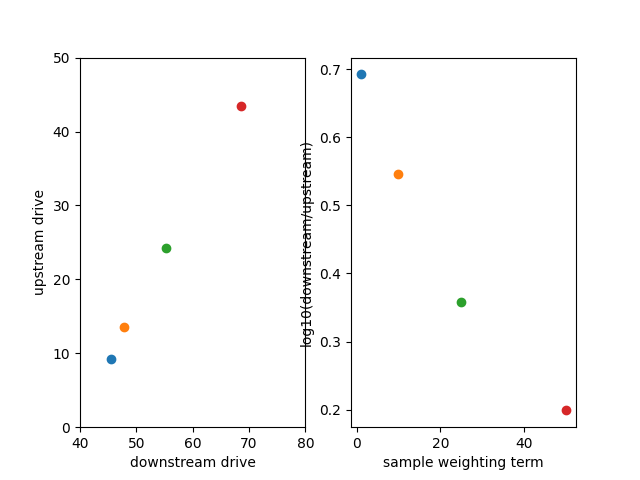

In [183]:
fig, axes = plt.subplots(ncols=2)
ax1 = axes[0]
ax2 = axes[1]
ax1.set_ylim(0,50)
ax1.set_xlim(40,80)
ax1.set_xlabel('downstream drive')
ax1.set_ylabel('upstream drive')
ax2.set_xlabel('sample weighting term')
ax2.set_ylabel('log10(downstream/upstream)')
for idx, h in enumerate(h_list):
    reg1_sw, reg2_sw = session.relative_input(h, Xtest, nlags=20, num_region1=20)
    ax1.scatter(reg1_sw, reg2_sw)
    ax2.scatter(sw_list[idx], np.log10(reg1_sw/reg2_sw))
    
    print(reg1_sw/reg2_sw)


In [23]:

laser_bounds, ctrl_bounds = session.adjustLaserBounds(pre=0, post=50)
climb_bounds = omitBoundInBounds(session.climbing_bounds, laser_bounds)
climb_bounds = omitBoundInBounds(climb_bounds, ctrl_bounds)
lasers = np.count_nonzero(bounds2Logical(laser_bounds))
climbs = np.count_nonzero(bounds2Logical(climb_bounds))

In [24]:
lasers/climbs

0.015320514898998086

In [184]:
output = pload('/home/diya/Documents/mp_opto/picklejar/coSweepRegsSW_20nlag_50post_50sw.pickle')
asymps = pload('/home/diya/Documents/mp_opto/picklejar/coSweepRegsSWasymps_20nlag_50post_50sw.pickle')

In [187]:
c_r2 = []
c_ratio = []
l_r2=[]
l_ratio=[]

sw_r2 = []
sw_ratio = []
lsw_r2=[]
lsw_ratio=[]

h_list =[]
h_sw_list = []

sesh=0

regs=[]

c_pos_asymps = asymps[sesh][0][0]
c_neg_asymps = asymps[sesh][1][0]

sw_pos_asymps = asymps[sesh][0][1]
sw_neg_asymps = asymps[sesh][1][1]

for run in output[sesh]:
    c=run[0]
    sw=run[1]
    
    
    regs.append(run[2][0])
    h_list.append(c[0])
    l_ratio.append(c[1])
    c_ratio.append(c[2])
    l_r2.append(c[3])
    c_r2.append(c[4])
    
    h_sw_list.append(sw[0])
    lsw_ratio.append(sw[1])
    sw_ratio.append(sw[2])
    lsw_r2.append(sw[3])
    sw_r2.append(sw[4])

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


(-2.0, 2.0)

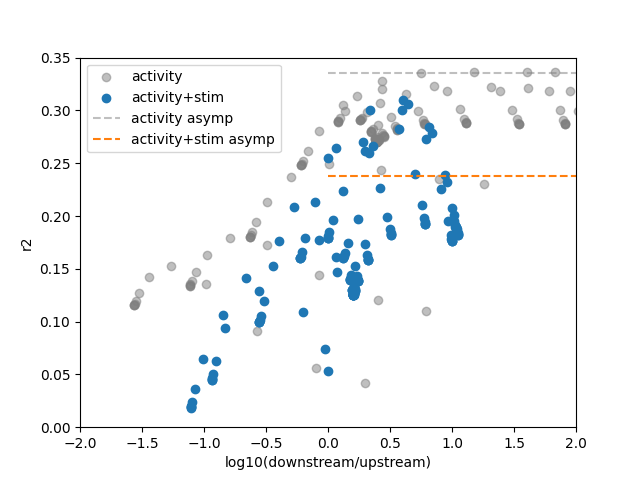

In [205]:
fig, ax = plt.subplots()
ax.scatter(c_ratio, c_r2, label='activity', color='gray', alpha=.5)
ax.scatter(sw_ratio, sw_r2, label='activity+stim')
#ax.axhline(c_neg_asymps, xmin=0, xmax=.5, linestyle='--')
ax.axhline(c_pos_asymps, xmin=.5, xmax=1, linestyle='--', label='activity asymp', color='gray', alpha=.5)
#ax.axhline(sw_neg_asymps, xmin=0, xmax=.5, linestyle='--', color='tab:orange', label=)
ax.axhline(sw_pos_asymps, xmin=.5, xmax=1, linestyle='--', color='tab:orange', label='activity+stim asymp')
ax.set_ylabel('r2')
ax.set_xlabel('log10(downstream/upstream)')
ax.set_ylim(0,.35)
ax.legend()
ax.set_xlim(-2,2)

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


(-2.0, 2.0)

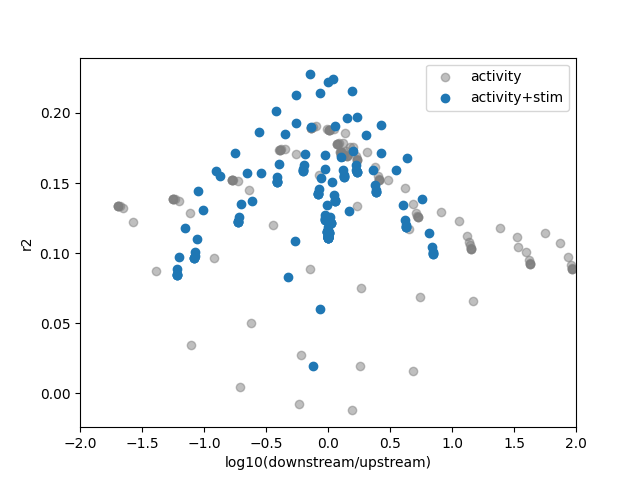

In [195]:

fig, ax = plt.subplots()
ax.scatter(l_ratio, l_r2, label='activity', color='gray', alpha=.5)
ax.scatter(lsw_ratio, lsw_r2, label='activity+stim')
#ax.axhline(c_neg_asymps, xmin=0, xmax=.5, linestyle='--')
#ax.axhline(sw_neg_asymps, xmin=0, xmax=.5, linestyle='--', color='tab:orange', label=)
ax.set_ylabel('r2')
ax.set_xlabel('log10(downstream/upstream)')
#ax.set_ylim(0,.35)
ax.legend()
ax.set_xlim(-2,2)

In [202]:
coutput = pload('/home/diya/Documents/mp_opto/picklejar/coSweepRegsCtrl_20nlag_50post_50sw.pickle')
casymps = pload('/home/diya/Documents/mp_opto/picklejar/coSweepRegsCtrlasymps_20nlag_50post_50sw.pickle')

In [203]:
ctrl_c_r2 = []
ctrl_c_ratio = []
ctrl_l_r2=[]
ctrl_l_ratio=[]

ctrl_sw_r2 = []
ctrl_sw_ratio = []
ctrl_lsw_r2=[]
ctrl_lsw_ratio=[]


ctrl_regs=[]

ctrl_h_list =[]
ctrl_h_sw_list = []
cc_pos_asymps = casymps[sesh][0][0]
cc_neg_asymps = casymps[sesh][1][0]

csw_pos_asymps = casymps[sesh][0][1]
csw_neg_asymps = casymps[sesh][1][1]

for run in coutput[sesh]:
    ctrl_c=run[0]
    ctrl_sw=run[1]
    
    ctrl_regs.append(run[2][0])
    
    ctrl_h_list.append(ctrl_c[0])
    ctrl_l_ratio.append(ctrl_c[1])
    ctrl_c_ratio.append(ctrl_c[2])
    ctrl_l_r2.append(ctrl_c[3])
    ctrl_c_r2.append(ctrl_c[4])
    
    ctrl_h_sw_list.append(ctrl_sw[0])
    ctrl_lsw_ratio.append(ctrl_sw[1])
    ctrl_sw_ratio.append(ctrl_sw[2])
    ctrl_lsw_r2.append(ctrl_sw[3])
    ctrl_sw_r2.append(ctrl_sw[4])

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


(-2.0, 2.0)

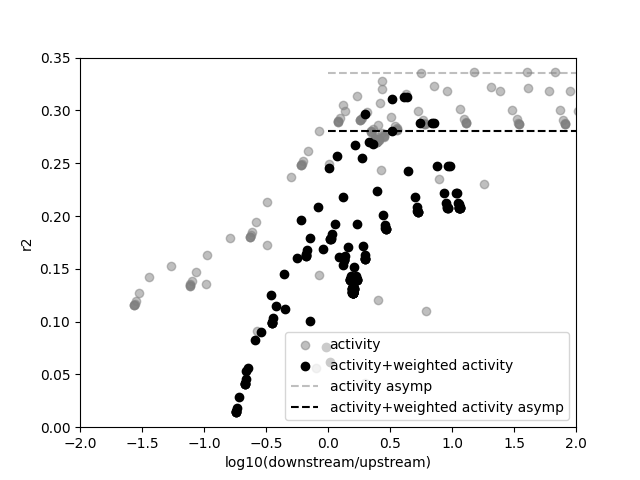

In [208]:
fig, ax = plt.subplots()
ax.scatter(ctrl_c_ratio, ctrl_c_r2, label='activity', color='gray', alpha=.5)
ax.scatter(ctrl_sw_ratio, ctrl_sw_r2, label='activity+weighted activity', color='black')
#ax.axhline(c_neg_asymps, xmin=0, xmax=.5, linestyle='--')
ax.axhline(cc_pos_asymps, xmin=.5, xmax=1, linestyle='--', label='activity asymp', color='gray', alpha=.5)
#ax.axhline(sw_neg_asymps, xmin=0, xmax=.5, linestyle='--', color='tab:orange', label=)
ax.axhline(csw_pos_asymps, xmin=.5, xmax=1, linestyle='--', color='black', label='activity+weighted activity asymp')
ax.set_ylabel('r2')
ax.set_xlabel('log10(downstream/upstream)')
ax.set_ylim(0,.35)
ax.legend()
ax.set_xlim(-2,2)

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


(-2.0, 2.0)

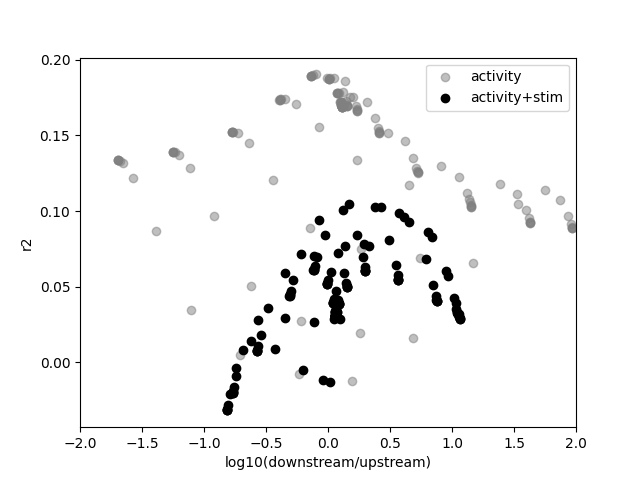

In [209]:

fig, ax = plt.subplots()
ax.scatter(ctrl_l_ratio, ctrl_l_r2, label='activity', color='gray', alpha=.5)
ax.scatter(ctrl_lsw_ratio, ctrl_lsw_r2, label='activity+stim', color='black')
#ax.axhline(c_neg_asymps, xmin=0, xmax=.5, linestyle='--')
#ax.axhline(sw_neg_asymps, xmin=0, xmax=.5, linestyle='--', color='tab:orange', label=)
ax.set_ylabel('r2')
ax.set_xlabel('log10(downstream/upstream)')
#ax.set_ylim(0,.35)
ax.legend()
ax.set_xlim(-2,2)
#ax.axhline(neg_asymps, xmin=0, xmax=.5, linestyle='--')
#ax.axhline(pos_asymps, xmin=.5, xmax=1, linestyle='--')

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


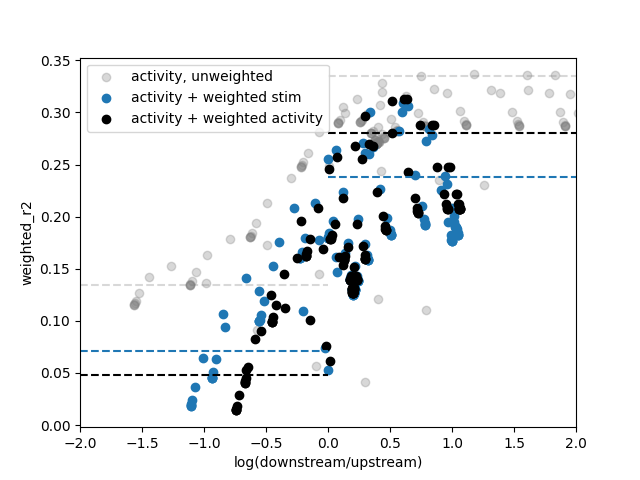

In [210]:
fig, ax = plt.subplots()
ax.scatter(ctrl_c_ratio, ctrl_c_r2, color='gray', alpha=.3, label='activity, unweighted')
ax.scatter(sw_ratio, sw_r2, color='tab:blue', label='activity + weighted stim')
ax.scatter(ctrl_sw_ratio, ctrl_sw_r2, color='black', label='activity + weighted activity')
ax.axhline(cc_neg_asymps, xmin=0, xmax=.5, linestyle='--', color='gray', alpha=.3)
ax.axhline(cc_pos_asymps, xmin=.5, xmax=1, linestyle='--', color='gray', alpha=.3)
ax.axhline(sw_neg_asymps, xmin=0, xmax=.5, linestyle='--', color='tab:blue')
ax.axhline(sw_pos_asymps, xmin=.5, xmax=1, linestyle='--', color='tab:blue')
ax.axhline(csw_neg_asymps, xmin=0, xmax=.5, linestyle='--', color='black')
ax.axhline(csw_pos_asymps, xmin=.5, xmax=1, linestyle='--', color='black')
#ax.set_ylim(-.05,.35)
ax.set_xlim(-2,2)
ax.set_xlabel('log(downstream/upstream)')
ax.set_ylabel('weighted_r2')
ax.legend()

# lets look at weights

In [211]:
percent_change_list=[]

h_col_list=[]
h_sw_col_list = []
good_c_ratio=[]
good_sw_ratio=[]

for idx in range(len(h_list)):
    h_ctrl_sw = ctrl_h_sw_list[idx]
    h_sw = h_sw_list[idx]
    if ctrl_sw_r2[idx] < 0.25:
        continue
    if sw_r2[idx] < 0.25:
        continue
    good_c_ratio.append(ctrl_c_ratio[idx])
    good_sw_ratio.append(sw_ratio[idx])
    #print('good!')
    h_col = collapse_h(h_ctrl_sw, nlags=20)
    h_sw_col = collapse_h(h_sw, nlags=20)
    
    h_col_list.append(h_col)
    h_sw_col_list.append(h_sw_col)
    
    percent_change_list.append(h_sw_col/h_col * 100)

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


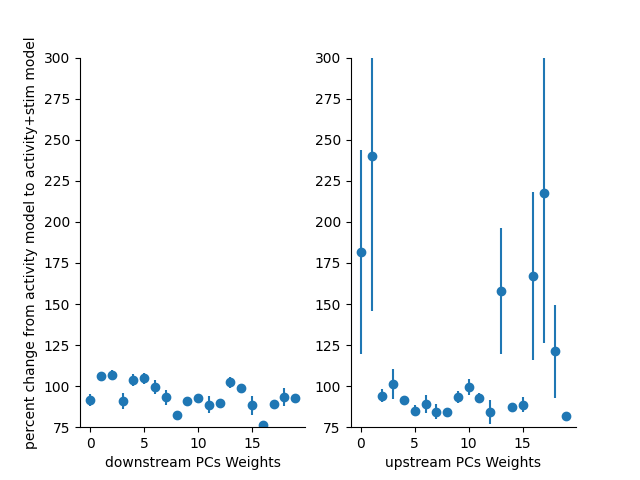

In [213]:
percent_change = np.array(percent_change_list)
stdz = np.std(percent_change, axis=0)
cfa_percent_change = percent_change[:,:20]
thal_percent_change = percent_change[:,20:]

cfa_std = stdz[:20]
thal_std = stdz[20:]

fig, ax = plt.subplots(ncols=2)
ax[0].errorbar(np.arange(20), np.average(cfa_percent_change, axis=0), yerr=cfa_std, fmt="o")
ax[1].errorbar(np.arange(20), np.average(thal_percent_change, axis=0), yerr=thal_std, fmt="o")
ax[0].set_ylabel('percent change from activity model to activity+stim model')
ax[0].set_xlabel('downstream PCs Weights')
ax[1].set_xlabel('upstream PCs Weights') 

ax[0].set_ylim(75, 300)
ax[1].set_ylim(75, 300)
ax[0].spines['top'].set_visible(False)
ax[0].spines['right'].set_visible(False)
ax[0].spines['top'].set_visible(False)
ax[0].spines['right'].set_visible(False)
ax[1].spines['top'].set_visible(False)
ax[1].spines['right'].set_visible(False)
ax[1].spines['top'].set_visible(False)
ax[1].spines['right'].set_visible(False)
#fig.suptitle('percent change to weights when including stims when fitting')
#fig.savefig('../results/grant_2024/weight change.pdf')

In [214]:
sorted_h_sw = [x for _, x in sorted(zip(good_sw_ratio, h_sw_col_list))]
sorted_h = [x for _, x in sorted(zip(good_c_ratio, h_col_list))]

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


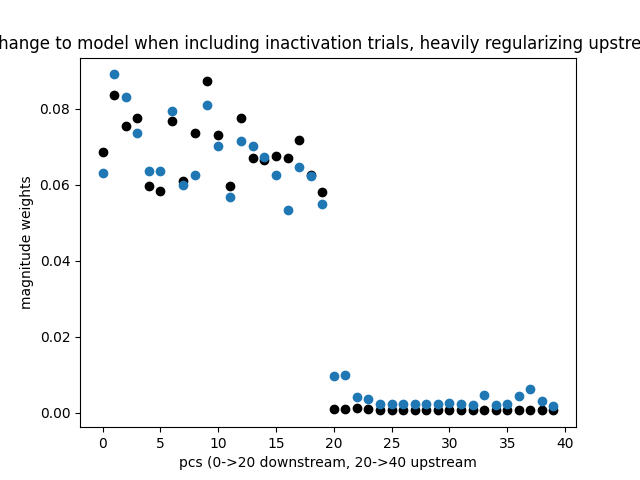

In [217]:
fig, ax = plt.subplots()
ax.set_title('change to model when including inactivation trials, heavily regularizing upstream')
ax.set_ylabel('magnitude weights')
ax.set_xlabel('pcs (0->20 downstream, 20->40 upstream')
ax.scatter(np.arange(len(sorted_h[-1])), sorted_h[-1], c='black')
ax.scatter(np.arange(len(sorted_h_sw[-1])), sorted_h_sw[-1])

In [72]:
output = pload('/home/diya/Documents/mp_opto/picklejar/toSweepRegsSW_20nlag_50post_25sw.pickle')
asymps = pload('/home/diya/Documents/mp_opto/picklejar/toSweepRegsSWasymps_20nlag_50post_25sw.pickle')

In [73]:
c_r2 = []
c_ratio = []
l_r2=[]
l_ratio=[]

sw_r2 = []
sw_ratio = []
lsw_r2=[]
lsw_ratio=[]

h_list =[]
h_sw_list = []

sesh=1

regs=[]

c_pos_asymps = asymps[sesh][0][0]
c_neg_asymps = asymps[sesh][1][0]

sw_pos_asymps = asymps[sesh][0][1]
sw_neg_asymps = asymps[sesh][1][1]

for run in output[sesh]:
    c=run[0]
    sw=run[1]
    
    
    regs.append(run[2][0])
    h_list.append(c[0])
    l_ratio.append(c[1])
    c_ratio.append(c[2])
    l_r2.append(c[3])
    c_r2.append(c[4])
    
    h_sw_list.append(sw[0])
    lsw_ratio.append(sw[1])
    sw_ratio.append(sw[2])
    lsw_r2.append(sw[3])
    sw_r2.append(sw[4])

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


(-2.0, 2.0)

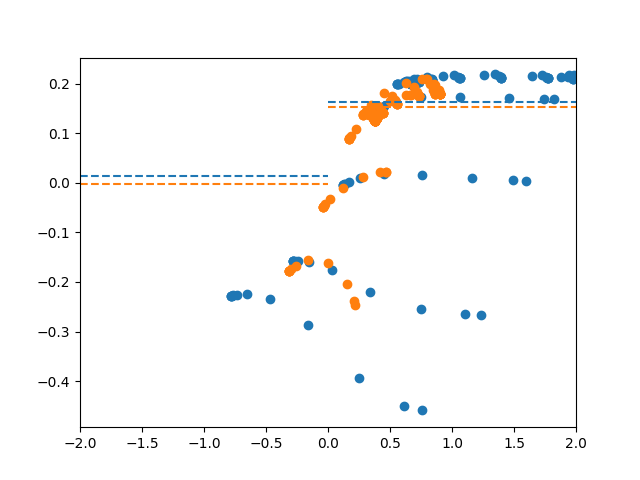

In [74]:
fig, ax = plt.subplots()
ax.scatter(c_ratio, c_r2)
ax.scatter(sw_ratio, sw_r2)
ax.axhline(c_neg_asymps, xmin=0, xmax=.5, linestyle='--')
ax.axhline(c_pos_asymps, xmin=.5, xmax=1, linestyle='--')
ax.axhline(sw_neg_asymps, xmin=0, xmax=.5, linestyle='--', color='tab:orange')
ax.axhline(sw_pos_asymps, xmin=.5, xmax=1, linestyle='--', color='tab:orange')
#ax.set_ylim(0,.35)
ax.set_xlim(-2,2)

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


(-2.0, 2.0)

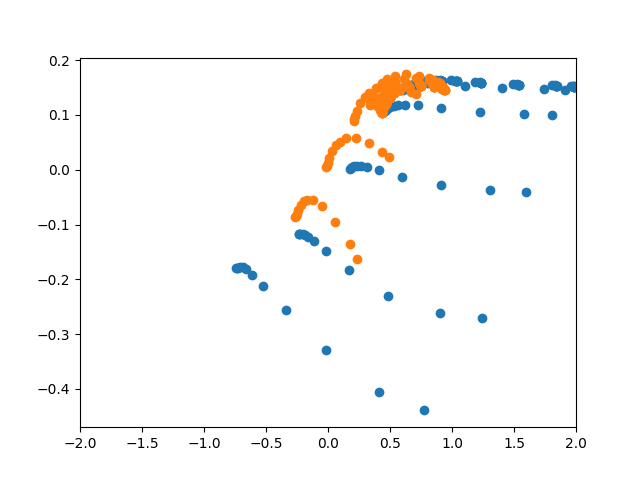

In [71]:
fig, ax = plt.subplots()
ax.scatter(l_ratio, l_r2)
ax.scatter(lsw_ratio, lsw_r2)
#ax.set_ylim(0,.25)
ax.set_xlim(-2,2)

In [61]:
coutput = pload('/home/diya/Documents/mp_opto/picklejar/coSweepRegsCtrl_20nlag_50post_25sw.pickle')
casymps = pload('/home/diya/Documents/mp_opto/picklejar/coSweepRegsCtrlasymps_20nlag_50post_25sw.pickle')

In [62]:
ctrl_c_r2 = []
ctrl_c_ratio = []
ctrl_l_r2=[]
ctrl_l_ratio=[]

ctrl_sw_r2 = []
ctrl_sw_ratio = []
ctrl_lsw_r2=[]
ctrl_lsw_ratio=[]


ctrl_regs=[]

ctrl_h_list =[]
ctrl_h_sw_list = []
cc_pos_asymps = casymps[sesh][0][0]
cc_neg_asymps = casymps[sesh][1][0]

csw_pos_asymps = casymps[sesh][0][1]
csw_neg_asymps = casymps[sesh][1][1]

for run in coutput[sesh]:
    ctrl_c=run[0]
    ctrl_sw=run[1]
    
    ctrl_regs.append(run[2][0])
    
    ctrl_h_list.append(ctrl_c[0])
    ctrl_l_ratio.append(ctrl_c[1])
    ctrl_c_ratio.append(ctrl_c[2])
    ctrl_l_r2.append(ctrl_c[3])
    ctrl_c_r2.append(ctrl_c[4])
    
    ctrl_h_sw_list.append(ctrl_sw[0])
    ctrl_lsw_ratio.append(ctrl_sw[1])
    ctrl_sw_ratio.append(ctrl_sw[2])
    ctrl_lsw_r2.append(ctrl_sw[3])
    ctrl_sw_r2.append(ctrl_sw[4])

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


(-2.0, 2.0)

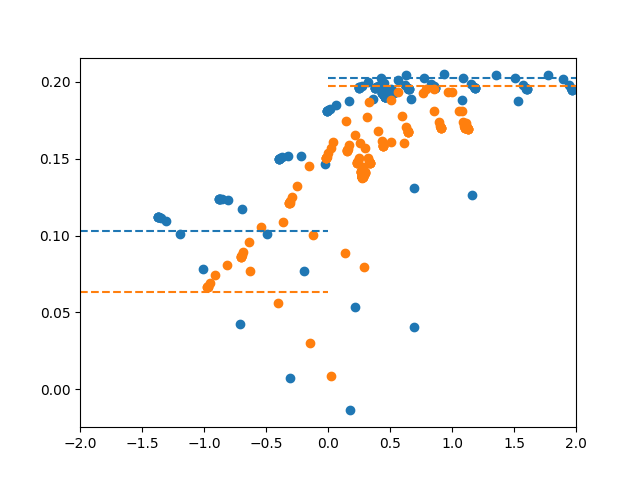

In [63]:
fig, ax = plt.subplots()
ax.scatter(ctrl_c_ratio, ctrl_c_r2)
ax.scatter(ctrl_sw_ratio, ctrl_sw_r2)
ax.axhline(cc_neg_asymps, xmin=0, xmax=.5, linestyle='--')
ax.axhline(cc_pos_asymps, xmin=.5, xmax=1, linestyle='--')
ax.axhline(csw_neg_asymps, xmin=0, xmax=.5, linestyle='--', color='tab:orange')
ax.axhline(csw_pos_asymps, xmin=.5, xmax=1, linestyle='--', color='tab:orange')
#ax.set_ylim(0,.35)
ax.set_xlim(-2,2)

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


(-2.0, 2.0)

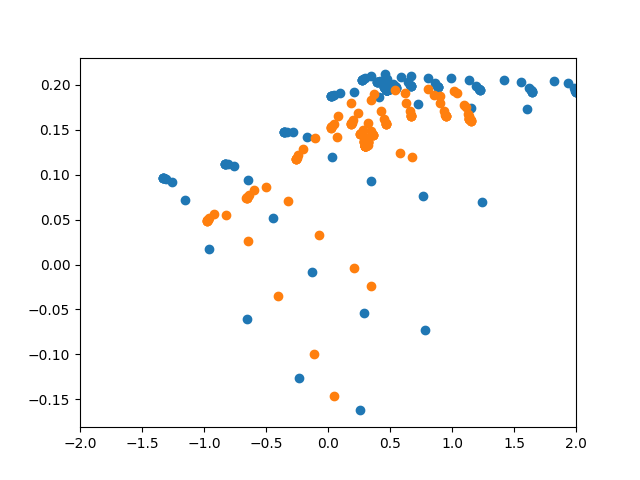

In [64]:
fig, ax = plt.subplots()
ax.scatter(ctrl_l_ratio, ctrl_l_r2)
ax.scatter(ctrl_lsw_ratio, ctrl_lsw_r2)
#ax.set_ylim(0,.2)
ax.set_xlim(-2,2)
#ax.axhline(neg_asymps, xmin=0, xmax=.5, linestyle='--')
#ax.axhline(pos_asymps, xmin=.5, xmax=1, linestyle='--')

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


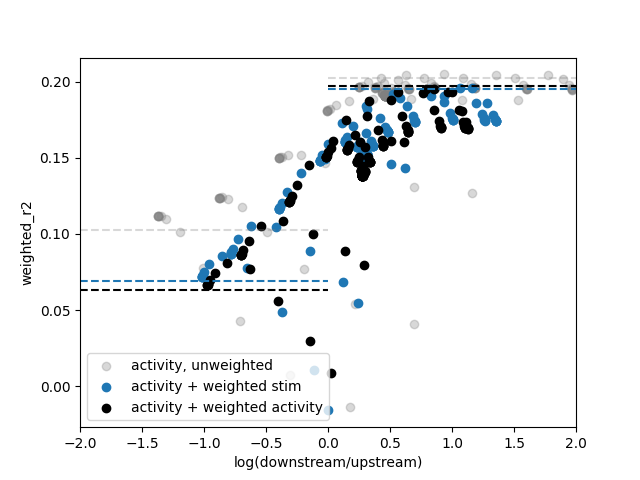

In [65]:
fig, ax = plt.subplots()
ax.scatter(ctrl_c_ratio, ctrl_c_r2, color='gray', alpha=.3, label='activity, unweighted')
ax.scatter(sw_ratio, sw_r2, color='tab:blue', label='activity + weighted stim')
ax.scatter(ctrl_sw_ratio, ctrl_sw_r2, color='black', label='activity + weighted activity')
ax.axhline(cc_neg_asymps, xmin=0, xmax=.5, linestyle='--', color='gray', alpha=.3)
ax.axhline(cc_pos_asymps, xmin=.5, xmax=1, linestyle='--', color='gray', alpha=.3)
ax.axhline(sw_neg_asymps, xmin=0, xmax=.5, linestyle='--', color='tab:blue')
ax.axhline(sw_pos_asymps, xmin=.5, xmax=1, linestyle='--', color='tab:blue')
ax.axhline(csw_neg_asymps, xmin=0, xmax=.5, linestyle='--', color='black')
ax.axhline(csw_pos_asymps, xmin=.5, xmax=1, linestyle='--', color='black')
#ax.set_ylim(-.05,.35)
ax.set_xlim(-2,2)
ax.set_xlabel('log(downstream/upstream)')
ax.set_ylabel('weighted_r2')
ax.legend()

# lets look at weights

In [122]:
percent_change_list=[]

h_col_list=[]
h_sw_col_list = []
good_c_ratio=[]
good_sw_ratio=[]

for idx in range(len(h_list)):
    h_ctrl_sw = ctrl_h_sw_list[idx]
    h_sw = h_sw_list[idx]
    if ctrl_sw_r2[idx] < 0.25:
        continue
    if sw_r2[idx] < 0.25:
        continue
    good_c_ratio.append(ctrl_c_ratio[idx])
    good_sw_ratio.append(sw_ratio[idx])
    #print('good!')
    h_col = collapse_h(h_ctrl_sw, nlags=20)
    h_sw_col = collapse_h(h_sw, nlags=20)
    
    h_col_list.append(h_col)
    h_sw_col_list.append(h_sw_col)
    
    percent_change_list.append(h_sw_col/h_col * 100)

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


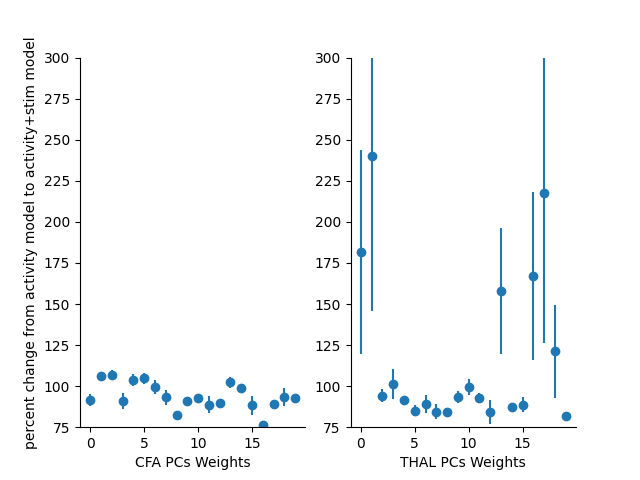

In [126]:
percent_change = np.array(percent_change_list)
stdz = np.std(percent_change, axis=0)
cfa_percent_change = percent_change[:,:20]
thal_percent_change = percent_change[:,20:]

cfa_std = stdz[:20]
thal_std = stdz[20:]

fig, ax = plt.subplots(ncols=2)
ax[0].errorbar(np.arange(20), np.average(cfa_percent_change, axis=0), yerr=cfa_std, fmt="o")
ax[1].errorbar(np.arange(20), np.average(thal_percent_change, axis=0), yerr=thal_std, fmt="o")
ax[0].set_ylabel('percent change from activity model to activity+stim model')
ax[0].set_xlabel('CFA PCs Weights')
ax[1].set_xlabel('THAL PCs Weights') 

ax[0].set_ylim(75, 300)
ax[1].set_ylim(75, 300)
ax[0].spines['top'].set_visible(False)
ax[0].spines['right'].set_visible(False)
ax[0].spines['top'].set_visible(False)
ax[0].spines['right'].set_visible(False)
ax[1].spines['top'].set_visible(False)
ax[1].spines['right'].set_visible(False)
ax[1].spines['top'].set_visible(False)
ax[1].spines['right'].set_visible(False)
#fig.suptitle('percent change to weights when including stims when fitting')
#fig.savefig('../results/grant_2024/weight change.pdf')

In [129]:
output = pload('/home/diya/Documents/mp_opto/picklejar/coSweepRegsSW_20nlag_50post_50sw.pickle')
asymps = pload('/home/diya/Documents/mp_opto/picklejar/coSweepRegsSWasymps_20nlag_50post_50sw.pickle')

In [130]:
c_r2 = []
c_ratio = []
l_r2=[]
l_ratio=[]

sw_r2 = []
sw_ratio = []
lsw_r2=[]
lsw_ratio=[]

h_list =[]
h_sw_list = []

sesh=1

regs=[]

c_pos_asymps = asymps[sesh][0][0]
c_neg_asymps = asymps[sesh][1][0]

sw_pos_asymps = asymps[sesh][0][1]
sw_neg_asymps = asymps[sesh][1][1]

for run in output[sesh]:
    c=run[0]
    sw=run[1]
    
    
    regs.append(run[2][0])
    h_list.append(c[0])
    l_ratio.append(c[1])
    c_ratio.append(c[2])
    l_r2.append(c[3])
    c_r2.append(c[4])
    
    h_sw_list.append(sw[0])
    lsw_ratio.append(sw[1])
    sw_ratio.append(sw[2])
    lsw_r2.append(sw[3])
    sw_r2.append(sw[4])

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


(-2.0, 2.0)

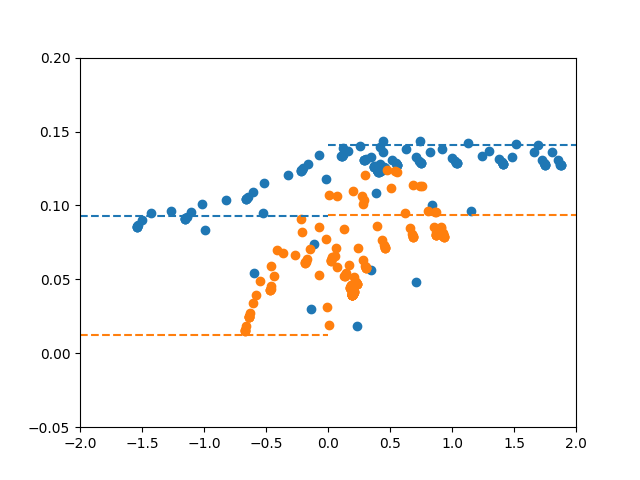

In [132]:
fig, ax = plt.subplots()
ax.scatter(c_ratio, c_r2)
ax.scatter(sw_ratio, sw_r2)
ax.axhline(c_neg_asymps, xmin=0, xmax=.5, linestyle='--')
ax.axhline(c_pos_asymps, xmin=.5, xmax=1, linestyle='--')
ax.axhline(sw_neg_asymps, xmin=0, xmax=.5, linestyle='--', color='tab:orange')
ax.axhline(sw_pos_asymps, xmin=.5, xmax=1, linestyle='--', color='tab:orange')
ax.set_ylim(-.05,.2)
ax.set_xlim(-2,2)

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


(-2.0, 2.0)

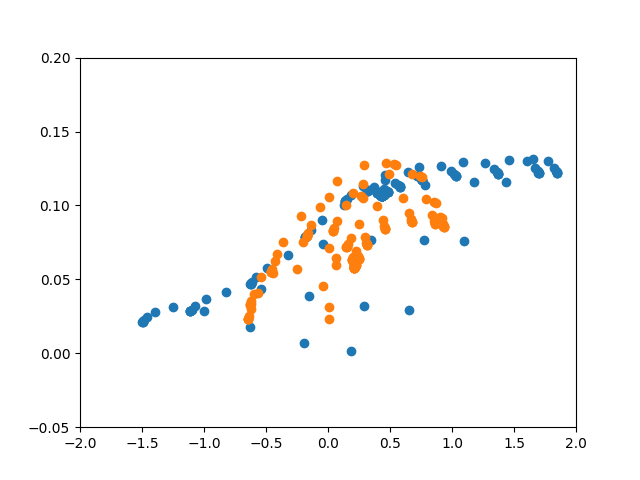

In [133]:
fig, ax = plt.subplots()
ax.scatter(l_ratio, l_r2)
ax.scatter(lsw_ratio, lsw_r2)
ax.set_ylim(-.05,.2)
ax.set_xlim(-2,2)

In [134]:
coutput = pload('/home/diya/Documents/mp_opto/picklejar/coSweepRegsCtrl_20nlag_50post_50sw.pickle')
casymps = pload('/home/diya/Documents/mp_opto/picklejar/coSweepRegsCtrlasymps_20nlag_50post_50sw.pickle')

In [135]:
ctrl_c_r2 = []
ctrl_c_ratio = []
ctrl_l_r2=[]
ctrl_l_ratio=[]

ctrl_sw_r2 = []
ctrl_sw_ratio = []
ctrl_lsw_r2=[]
ctrl_lsw_ratio=[]


ctrl_regs=[]

ctrl_h_list =[]
ctrl_h_sw_list = []
cc_pos_asymps = casymps[sesh][0][0]
cc_neg_asymps = casymps[sesh][1][0]

csw_pos_asymps = casymps[sesh][0][1]
csw_neg_asymps = casymps[sesh][1][1]

for run in coutput[sesh]:
    ctrl_c=run[0]
    ctrl_sw=run[1]
    
    ctrl_regs.append(run[2][0])
    
    ctrl_h_list.append(ctrl_c[0])
    ctrl_l_ratio.append(ctrl_c[1])
    ctrl_c_ratio.append(ctrl_c[2])
    ctrl_l_r2.append(ctrl_c[3])
    ctrl_c_r2.append(ctrl_c[4])
    
    ctrl_h_sw_list.append(ctrl_sw[0])
    ctrl_lsw_ratio.append(ctrl_sw[1])
    ctrl_sw_ratio.append(ctrl_sw[2])
    ctrl_lsw_r2.append(ctrl_sw[3])
    ctrl_sw_r2.append(ctrl_sw[4])

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


(-2.0, 2.0)

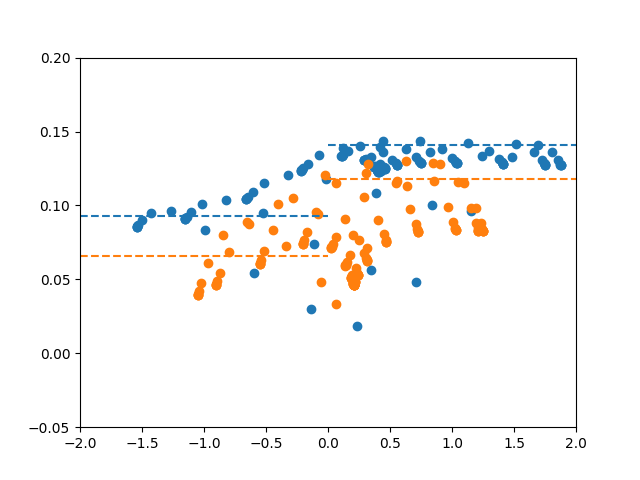

In [136]:
fig, ax = plt.subplots()
ax.scatter(ctrl_c_ratio, ctrl_c_r2)
ax.scatter(ctrl_sw_ratio, ctrl_sw_r2)
ax.axhline(cc_neg_asymps, xmin=0, xmax=.5, linestyle='--')
ax.axhline(cc_pos_asymps, xmin=.5, xmax=1, linestyle='--')
ax.axhline(csw_neg_asymps, xmin=0, xmax=.5, linestyle='--', color='tab:orange')
ax.axhline(csw_pos_asymps, xmin=.5, xmax=1, linestyle='--', color='tab:orange')
ax.set_ylim(-.05,.2)
ax.set_xlim(-2,2)

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


(-2.0, 2.0)

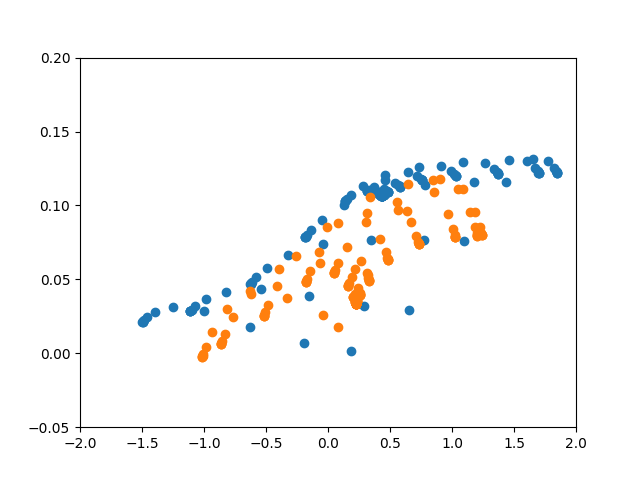

In [137]:
fig, ax = plt.subplots()
ax.scatter(ctrl_l_ratio, ctrl_l_r2)
ax.scatter(ctrl_lsw_ratio, ctrl_lsw_r2)
ax.set_ylim(-.05,.2)
ax.set_xlim(-2,2)
#ax.axhline(neg_asymps, xmin=0, xmax=.5, linestyle='--')
#ax.axhline(pos_asymps, xmin=.5, xmax=1, linestyle='--')

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


(-2.0, 2.0)

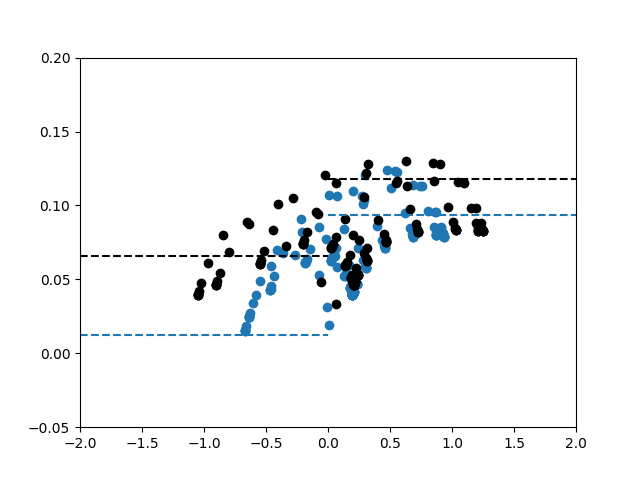

In [138]:
fig, ax = plt.subplots()
ax.scatter(sw_ratio, sw_r2, color='tab:blue')
ax.scatter(ctrl_sw_ratio, ctrl_sw_r2, color='black')
ax.axhline(sw_neg_asymps, xmin=0, xmax=.5, linestyle='--', color='tab:blue')
ax.axhline(sw_pos_asymps, xmin=.5, xmax=1, linestyle='--', color='tab:blue')
ax.axhline(csw_neg_asymps, xmin=0, xmax=.5, linestyle='--', color='black')
ax.axhline(csw_pos_asymps, xmin=.5, xmax=1, linestyle='--', color='black')
ax.set_ylim(-.05,.2)
ax.set_xlim(-2,2)

# lets look at weights

In [157]:
percent_change_list=[]

h_col_list=[]
h_sw_col_list = []
good_c_ratio=[]
good_sw_ratio=[]

for idx in range(len(h_list)):
    h_ctrl_sw = ctrl_h_sw_list[idx]
    h_sw = h_sw_list[idx]
    if ctrl_sw_r2[idx] < 0.1:
        continue
    if sw_r2[idx] < 0.1:
        continue
    good_c_ratio.append(ctrl_c_ratio[idx])
    good_sw_ratio.append(sw_ratio[idx])
    #print('good!')
    h_col = collapse_h(h_ctrl_sw, nlags=20)
    h_sw_col = collapse_h(h_sw, nlags=20)
    
    h_col_list.append(h_col)
    h_sw_col_list.append(h_sw_col)
    
    percent_change_list.append(h_sw_col/h_col * 100)

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


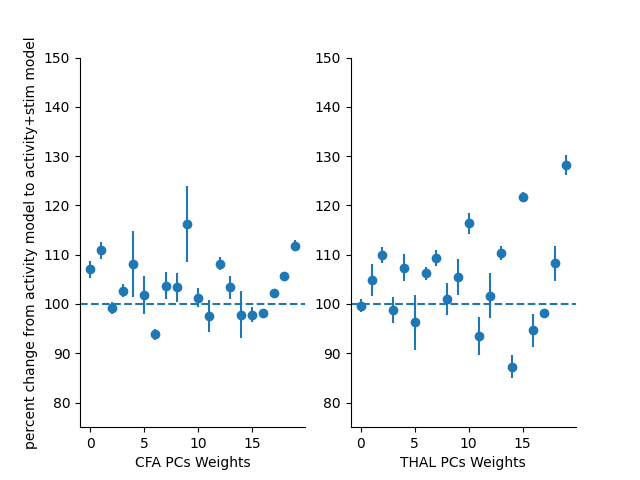

In [158]:
percent_change = np.array(percent_change_list)
stdz = np.std(percent_change, axis=0)
cfa_percent_change = percent_change[:,:20]
thal_percent_change = percent_change[:,20:]

cfa_std = stdz[:20]
thal_std = stdz[20:]

fig, ax = plt.subplots(ncols=2)
ax[0].errorbar(np.arange(20), np.average(cfa_percent_change, axis=0), yerr=cfa_std, fmt="o")
ax[1].errorbar(np.arange(20), np.average(thal_percent_change, axis=0), yerr=thal_std, fmt="o")
ax[0].set_ylabel('percent change from activity model to activity+stim model')
ax[0].set_xlabel('CFA PCs Weights')
ax[1].set_xlabel('THAL PCs Weights') 

ax[0].set_ylim(75, 150)
ax[1].set_ylim(75, 150)
ax[0].spines['top'].set_visible(False)
ax[0].spines['right'].set_visible(False)
ax[0].spines['top'].set_visible(False)
ax[0].spines['right'].set_visible(False)
ax[1].spines['top'].set_visible(False)
ax[1].spines['right'].set_visible(False)
ax[1].spines['top'].set_visible(False)
ax[1].spines['right'].set_visible(False)
ax[1].axhline(100, linestyle='--')
ax[0].axhline(100, linestyle='--')
#fig.suptitle('percent change to weights when including stims when fitting')
#fig.savefig('../results/grant_2024/weight change.pdf')

In [159]:
sorted_h_sw = [x for _, x in sorted(zip(good_sw_ratio, h_sw_col_list))]
sorted_h = [x for _, x in sorted(zip(good_c_ratio, h_col_list))]

14


/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


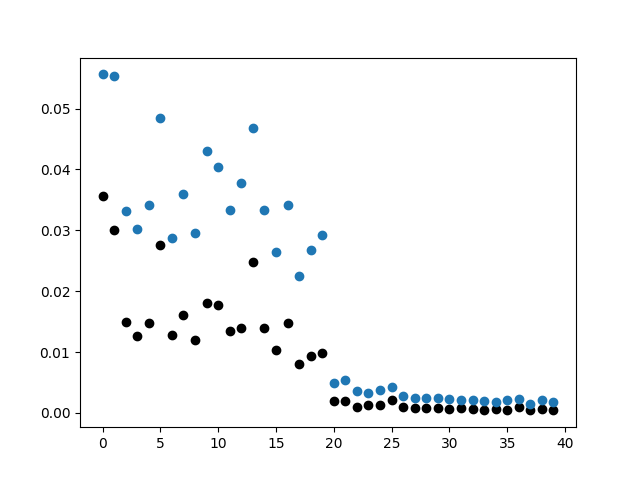

In [161]:
fig, ax = plt.subplots()
ax.scatter(np.arange(len(sorted_h[-5])), sorted_h[-5], c='black')
ax.scatter(np.arange(len(sorted_h_sw[-5])), sorted_h_sw[-5])
print(len(sorted_h))

In [197]:
session_path = '../data/to/to3/to3_06052024'
session = MPOptoClass(session_path)

masking THAL, 300<x<1000
love


In [201]:
laser_bounds, ctrl_bounds = session.adjustLaserBounds(pre=0, post=50,only_climb=True)
climb_bounds = omitBoundInBounds(session.climbing_bounds, laser_bounds)
climb_bounds = omitBoundInBounds(climb_bounds, ctrl_bounds)
lasers = np.count_nonzero(bounds2Logical(laser_bounds))
climbs = np.count_nonzero(bounds2Logical(climb_bounds))

In [202]:
lasers/climbs

0.06314003607128664

# graveyard

In [77]:
output = pload('/home/diya/Documents/mp_opto/picklejar/coSweepRegsSW_20nlag_50post_25sw_skew.pickle')
#asymps = pload('/home/diya/Documents/mp_opto/picklejar/coSweepRegsSWSkewasymps_20nlag_50post_25sw.pickle')

In [79]:
c_r2 = []
c_ratio = []
l_r2=[]
l_ratio=[]

sw_r2 = []
sw_ratio = []
lsw_r2=[]
lsw_ratio=[]

h_list =[]
h_sw_list = []

sesh=0

regs=[]

#pos_asymps = asymps[sesh][0][0]
#neg_asymps = asymps[sesh][1][0]

for run in output[sesh]:
    c=run[0]
    sw=run[1]
    
    
    regs.append(run[2][0])
    h_list.append(c[0])
    l_ratio.append(c[1])
    c_ratio.append(c[2])
    l_r2.append(c[3])
    c_r2.append(c[4])
    
    h_sw_list.append(sw[0])
    lsw_ratio.append(sw[1])
    sw_ratio.append(sw[2])
    lsw_r2.append(sw[3])
    sw_r2.append(sw[4])

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


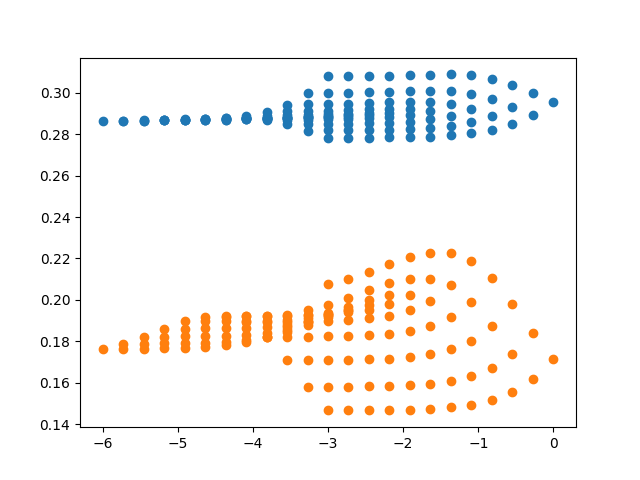

In [80]:
regs = np.array(regs)
reg_ratio = np.log10(np.array(regs[:,0] / regs[:,1]))
fig, ax = plt.subplots()
ax.scatter(reg_ratio, c_r2)
ax.scatter(reg_ratio, sw_r2)

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


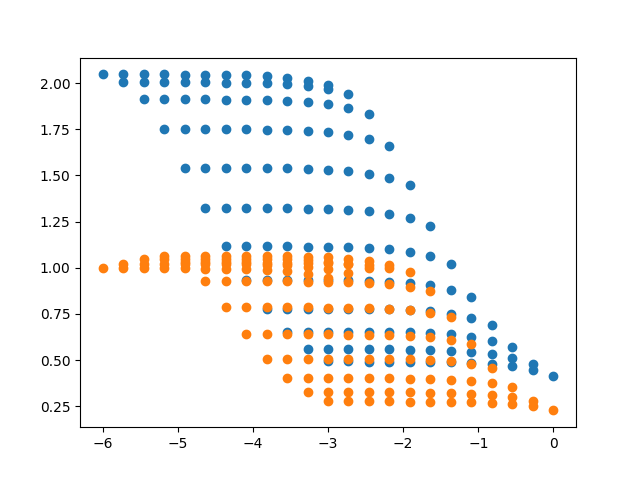

In [83]:
fig, ax = plt.subplots()
ax.scatter(reg_ratio, c_ratio)
ax.scatter(reg_ratio, sw_ratio)

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


(0.0, 2.5)

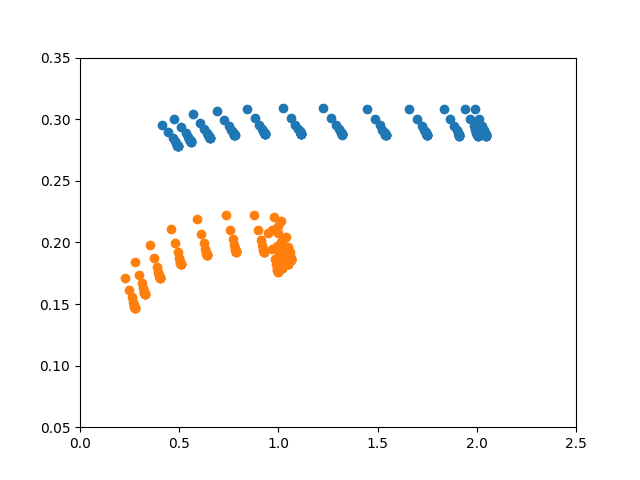

In [86]:
fig, ax = plt.subplots()
ax.scatter(c_ratio, c_r2)
ax.scatter(sw_ratio, sw_r2)
#ax.axhline(neg_asymps, xmin=0, xmax=.5, linestyle='--')
#ax.axhline(pos_asymps, xmin=.5, xmax=1, linestyle='--')
ax.set_ylim(.05,.35)
ax.set_xlim(0,2.5)

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


(-2.0, 2.0)

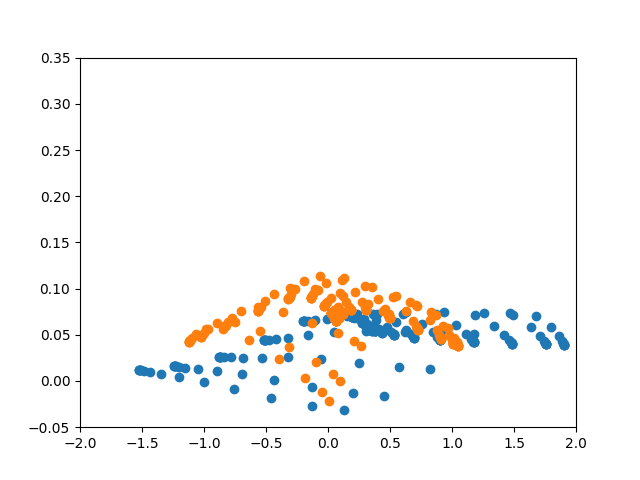

In [42]:
fig, ax = plt.subplots()
ax.scatter(l_ratio, l_r2)
ax.scatter(lsw_ratio, lsw_r2)
ax.set_ylim(-.05,.35)
ax.set_xlim(-2,2)

# graveyard

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


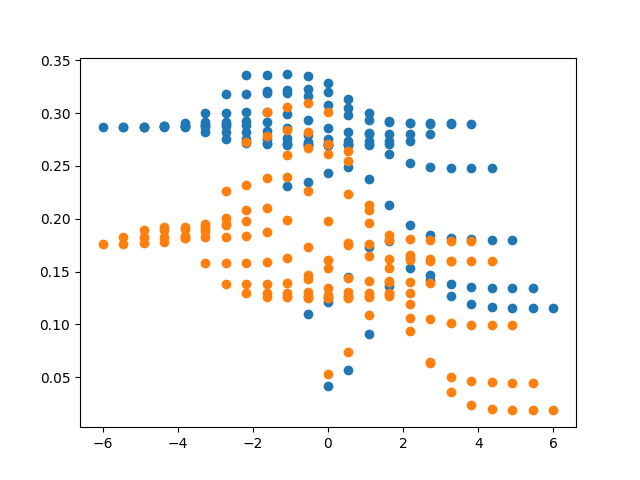

In [104]:
regs = np.array(regs)
reg_ratio = np.log10(np.array(regs[:,0] / regs[:,1]))
fig, ax = plt.subplots()
ax.scatter(reg_ratio, c_r2)
ax.scatter(reg_ratio, sw_r2)

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


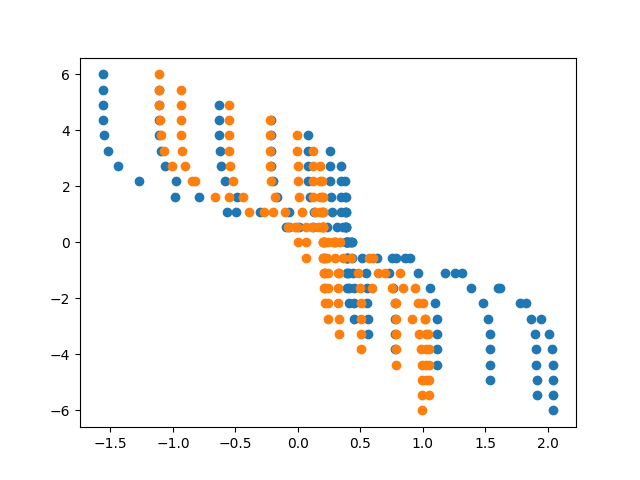

In [105]:
fig, ax = plt.subplots()
ax.scatter(c_ratio, reg_ratio)
ax.scatter(sw_ratio, reg_ratio)

In [36]:
output = pload('/home/diya/Documents/mp_opto/picklejar/bulkSweepRegsSW_20nlag_50post_10sw.pickle')
asymps = pload('/home/diya/Documents/mp_opto/picklejar/bulkSweepRegsSWasymps_20nlag_50post_10sw.pickle')

In [38]:
c_r2 = []
c_ratio = []
l_r2=[]
l_ratio=[]

sw_r2 = []
sw_ratio = []
lsw_r2=[]
lsw_ratio=[]

h_list =[]
h_sw_list = []

sesh=4

regs=[]

pos_asymps = asymps[sesh][0][0]
neg_asymps = asymps[sesh][1][0]

for run in output[sesh]:
    c=run[0]
    sw=run[1]
    
    
    regs.append(run[2][0])
    h_list.append(c[0])
    l_ratio.append(c[1])
    c_ratio.append(c[2])
    l_r2.append(c[3])
    c_r2.append(c[4])
    
    h_sw_list.append(sw[0])
    lsw_ratio.append(sw[1])
    sw_ratio.append(sw[2])
    lsw_r2.append(sw[3])
    sw_r2.append(sw[4])

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


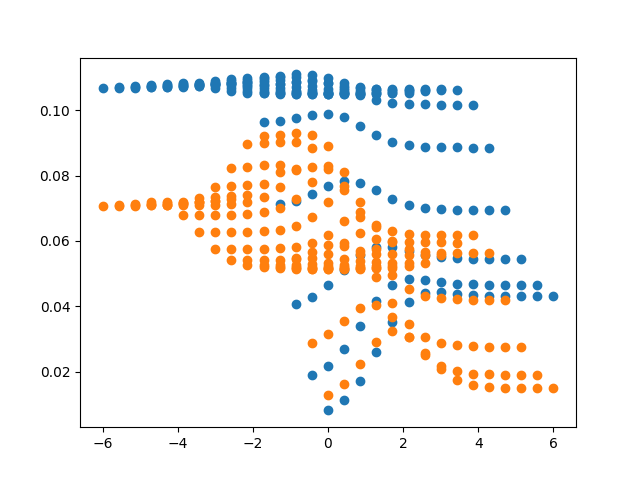

In [39]:
regs = np.array(regs)
reg_ratio = np.log10(np.array(regs[:,0] / regs[:,1]))
fig, ax = plt.subplots()
ax.scatter(reg_ratio, c_r2)
ax.scatter(reg_ratio, sw_r2)

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


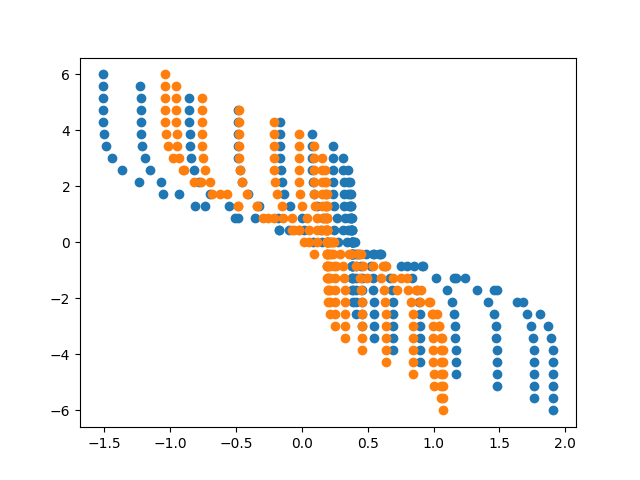

In [40]:
fig, ax = plt.subplots()
ax.scatter(c_ratio, reg_ratio)
ax.scatter(sw_ratio, reg_ratio)

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


NameError: name 'neg_asymps' is not defined

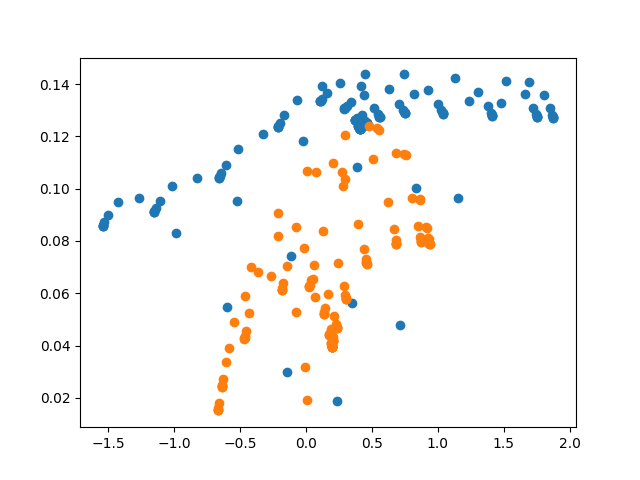

In [162]:
fig, ax = plt.subplots()
ax.scatter(c_ratio, c_r2)
ax.scatter(sw_ratio, sw_r2)
ax.axhline(neg_asymps, xmin=0, xmax=.5, linestyle='--')
ax.axhline(pos_asymps, xmin=.5, xmax=1, linestyle='--')
ax.set_ylim(-.05,.2)
ax.set_xlim(-2,2)

In [214]:
output = pload('/home/diya/Documents/mp_opto/picklejar/coSweepRegsCtrl_20nlag_50post_5sw.pickle')
asymps = pload('/home/diya/Documents/mp_opto/picklejar/coSweepRegsCtrlasymps_20nlag_50post_5sw.pickle')

In [215]:
c_r2 = []
c_ratio = []
l_r2=[]
l_ratio=[]

sw_r2 = []
sw_ratio = []
lsw_r2=[]
lsw_ratio=[]

h_list =[]
h_sw_list = []

sesh=0

regs=[]

c_pos_asymps = asymps[sesh][0][0]
c_neg_asymps = asymps[sesh][1][0]

sw_pos_asymps = asymps[sesh][0][1]
sw_neg_asymps = asymps[sesh][1][1]

for run in output[sesh]:
    c=run[0]
    sw=run[1]
    
    
    regs.append(run[2][0])
    h_list.append(c[0])
    l_ratio.append(c[1])
    c_ratio.append(c[2])
    l_r2.append(c[3])
    c_r2.append(c[4])
    
    h_sw_list.append(sw[0])
    lsw_ratio.append(sw[1])
    sw_ratio.append(sw[2])
    lsw_r2.append(sw[3])
    sw_r2.append(sw[4])

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


(-2.0, 2.0)

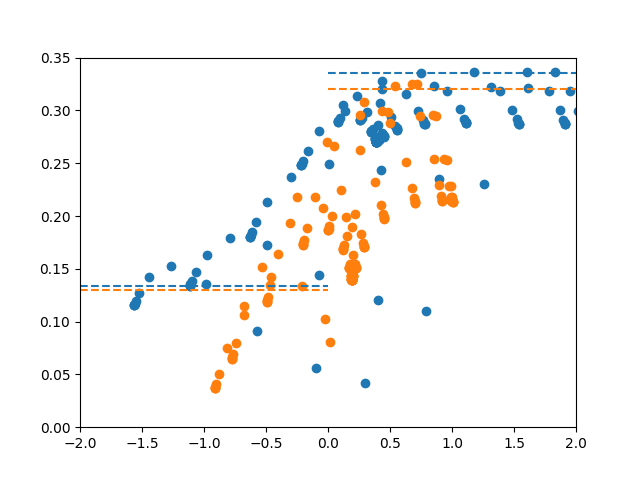

In [217]:
fig, ax = plt.subplots()
ax.scatter(c_ratio, c_r2)
ax.scatter(sw_ratio, sw_r2)
ax.axhline(c_neg_asymps, xmin=0, xmax=.5, linestyle='--')
ax.axhline(c_pos_asymps, xmin=.5, xmax=1, linestyle='--')
ax.axhline(sw_neg_asymps, xmin=0, xmax=.5, linestyle='--', color='tab:orange')
ax.axhline(sw_pos_asymps, xmin=.5, xmax=1, linestyle='--', color='tab:orange')
ax.set_ylim(0,.35)
ax.set_xlim(-2,2)

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


(-2.0, 2.0)

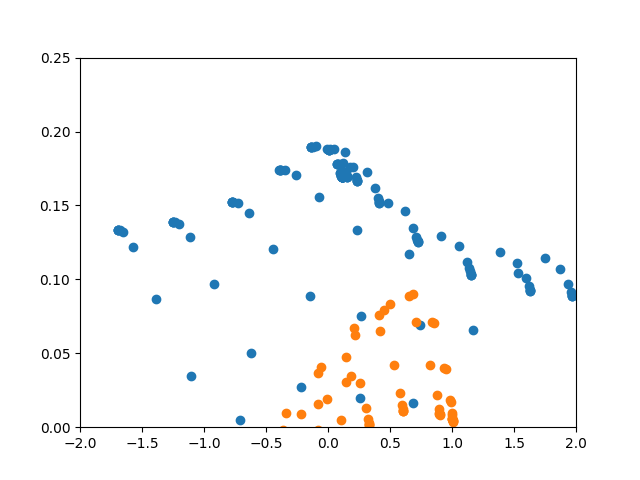

In [218]:
fig, ax = plt.subplots()
ax.scatter(l_ratio, l_r2)
ax.scatter(lsw_ratio, lsw_r2)
ax.set_ylim(0,.25)
ax.set_xlim(-2,2)

In [219]:
coutput = pload('/home/diya/Documents/mp_opto/picklejar/coSweepRegsCtrl_20nlag_50post_50sw.pickle')
casymps = pload('/home/diya/Documents/mp_opto/picklejar/coSweepRegsCtrlasymps_20nlag_50post_50sw.pickle')

In [220]:
ctrl_c_r2 = []
ctrl_c_ratio = []
ctrl_l_r2=[]
ctrl_l_ratio=[]

ctrl_sw_r2 = []
ctrl_sw_ratio = []
ctrl_lsw_r2=[]
ctrl_lsw_ratio=[]


ctrl_regs=[]

ctrl_h_list =[]
ctrl_h_sw_list = []
cc_pos_asymps = casymps[sesh][0][0]
cc_neg_asymps = casymps[sesh][1][0]

csw_pos_asymps = casymps[sesh][0][1]
csw_neg_asymps = casymps[sesh][1][1]

for run in coutput[sesh]:
    ctrl_c=run[0]
    ctrl_sw=run[1]
    
    ctrl_regs.append(run[2][0])
    
    ctrl_h_list.append(ctrl_c[0])
    ctrl_l_ratio.append(ctrl_c[1])
    ctrl_c_ratio.append(ctrl_c[2])
    ctrl_l_r2.append(ctrl_c[3])
    ctrl_c_r2.append(ctrl_c[4])
    
    ctrl_h_sw_list.append(ctrl_sw[0])
    ctrl_lsw_ratio.append(ctrl_sw[1])
    ctrl_sw_ratio.append(ctrl_sw[2])
    ctrl_lsw_r2.append(ctrl_sw[3])
    ctrl_sw_r2.append(ctrl_sw[4])

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


(-2.0, 2.0)

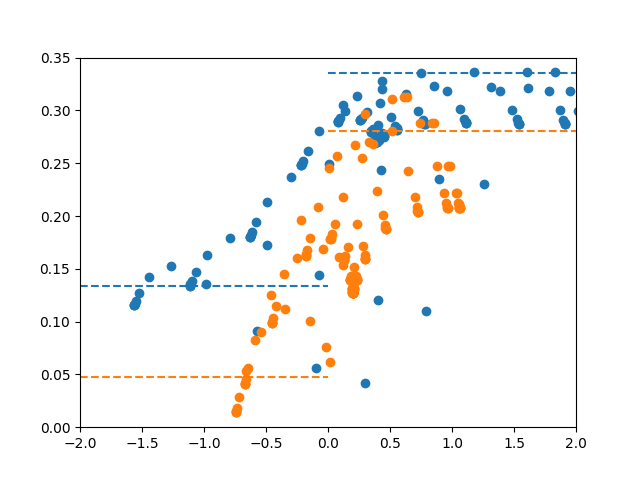

In [221]:
fig, ax = plt.subplots()
ax.scatter(ctrl_c_ratio, ctrl_c_r2)
ax.scatter(ctrl_sw_ratio, ctrl_sw_r2)
ax.axhline(cc_neg_asymps, xmin=0, xmax=.5, linestyle='--')
ax.axhline(cc_pos_asymps, xmin=.5, xmax=1, linestyle='--')
ax.axhline(csw_neg_asymps, xmin=0, xmax=.5, linestyle='--', color='tab:orange')
ax.axhline(csw_pos_asymps, xmin=.5, xmax=1, linestyle='--', color='tab:orange')
ax.set_ylim(0,.35)
ax.set_xlim(-2,2)

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


(-2.0, 2.0)

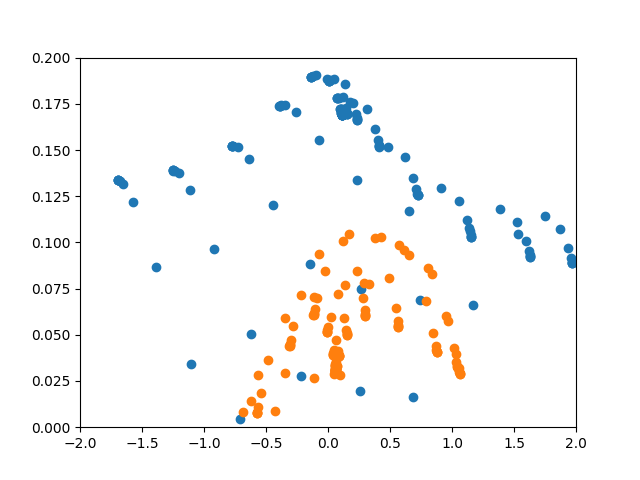

In [192]:
fig, ax = plt.subplots()
ax.scatter(ctrl_l_ratio, ctrl_l_r2)
ax.scatter(ctrl_lsw_ratio, ctrl_lsw_r2)
ax.set_ylim(0,.2)
ax.set_xlim(-2,2)
#ax.axhline(neg_asymps, xmin=0, xmax=.5, linestyle='--')
#ax.axhline(pos_asymps, xmin=.5, xmax=1, linestyle='--')

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


(-2.0, 2.0)

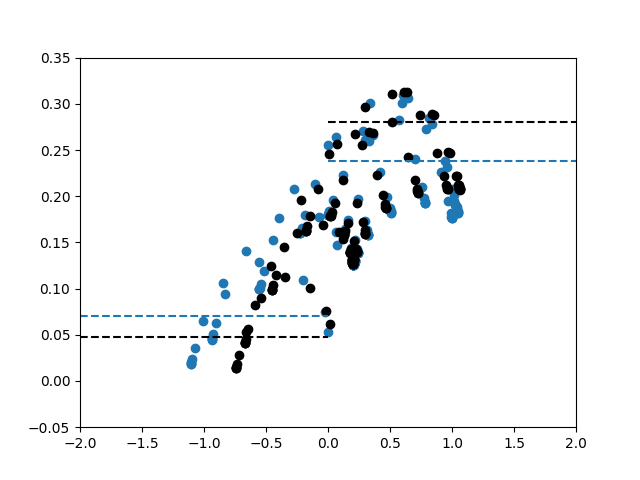

In [193]:
fig, ax = plt.subplots()
ax.scatter(sw_ratio, sw_r2, color='tab:blue')
ax.scatter(ctrl_sw_ratio, ctrl_sw_r2, color='black')
ax.axhline(sw_neg_asymps, xmin=0, xmax=.5, linestyle='--', color='tab:blue')
ax.axhline(sw_pos_asymps, xmin=.5, xmax=1, linestyle='--', color='tab:blue')
ax.axhline(csw_neg_asymps, xmin=0, xmax=.5, linestyle='--', color='black')
ax.axhline(csw_pos_asymps, xmin=.5, xmax=1, linestyle='--', color='black')
ax.set_ylim(-.05,.35)
ax.set_xlim(-2,2)